<h2 style="color:blue" align="center">Handwritten digits classification using neural network</h2>

Source: https://www.youtube.com/watch?v=iqQgED9vV7k&list=PLeo1K3hjS3uu7CxAacxVndI4bE_o3BDtO&index=7

In this notebook we will classify handwritten digits using a simple neural network which has only input and output layers. We will than add a hidden layer and see how the performance of the model improves

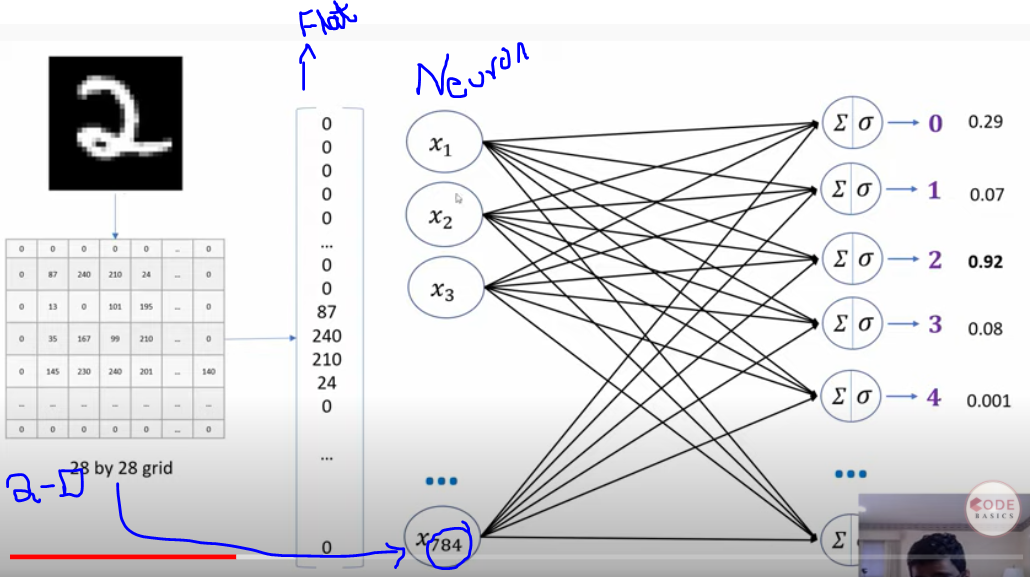

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
#lOAD Handwritten dataset from mnist
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

11501568/11490434 [==============================] - 31s 3us/step


In [3]:
len(X_train)

60000

In [4]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

> Here 60000 is the no of samples, 28 and 28 are shape of the each individual image. Each image is 28 to 28 shape

In [26]:
y_train.shape

(60000,)

In [5]:
X_train[0].shape  # it's 28*28 pixel image data. 

(28, 28)

In [5]:
X_train[0] 

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

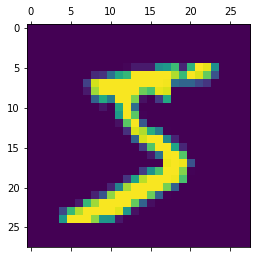

In [6]:
plt.matshow(X_train[0]) 

#wherever the number is there in above result that is the yellow portion in below image i.e
# those pixel values represent the number. Wherever 0 is there that is the purpule portion below.  

In [7]:
y_train[0]

5

> This 1st data is represent digit 5

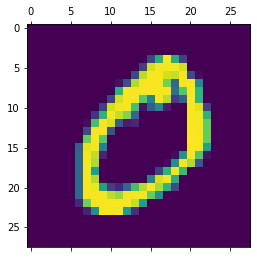

In [16]:
plt.matshow(X_train[1]) 

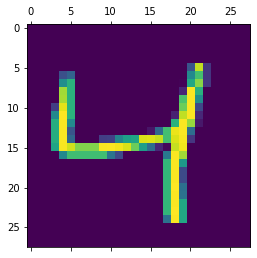

In [17]:
plt.matshow(X_train[2]) 

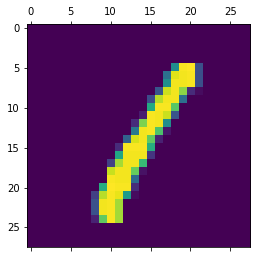

In [25]:
plt.matshow(X_train[3]) 

In [24]:
y_train[0:5]

array([5, 0, 4, 1, 9], dtype=uint8)

## 1. Data Preprocessing

In [19]:
#  Scale the data

X_train = X_train / 255  # here dividsion is done to scale the data into same units. 
X_test = X_test / 255

In [20]:
X_train[0]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000

In [21]:
# Flatten the 28*28 2-Dimention grid data to single flat data
X_train_flattened = X_train.reshape(len(X_train), 28*28)  # X_train.reshape(60000, 784)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [22]:
X_train_flattened.shape  # 28*28 = 784

(60000, 784)

In [23]:
X_train_flattened[0]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

## 2. APPLY DL Model -  Sequential

<h3 style='color:purple'>Very simple neural network with no hidden layers</h3>

<img src="digits_nn.jpg" />

In [28]:
# From the definition of Keras documentation the Sequential model is a linear stack of layers.

#Define simple Neural Network
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
])

# Dense is becase every input neuron is connected to output also, hence its dense
# 10, means 10 possible output values. input_shape is no of input neorons, here its 784(28*28)


#Every time we need to compile Neural network with set of below parameters
model.compile(optimizer='adam', # for efficient training, it helps to reach global minima in optimal way during backpropagation
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_flattened, y_train, epochs=5)
# Here epochs 5 means no of iteration our Neural network is going to run

Epoch 1/5
1875/1875 [==============================] - 2s 808us/step - loss: 2.1881 - accuracy: 0.5902
Epoch 2/5
1875/1875 [==============================] - 1s 793us/step - loss: 1.9772 - accuracy: 0.7003
Epoch 3/5
1875/1875 [==============================] - 2s 811us/step - loss: 1.7909 - accuracy: 0.7422
Epoch 4/5
1875/1875 [==============================] - 2s 809us/step - loss: 1.6271 - accuracy: 0.7600
Epoch 5/5
1875/1875 [==============================] - 2s 832us/step - loss: 1.4844 - accuracy: 0.7753


> In Each step accuracy is increasing, 5th epoch is 77.5% accuracy

In [29]:
#Test/Evaluate the test dataset --> model.evaluate(X_test, ytest)
model.evaluate(X_test_flattened, y_test)

313/313 [==============================] - 0s 725us/step - loss: 1.4045 - accuracy: 0.8008


[1.4045056104660034, 0.8008000254631042]

> It shows test data is accuracy=0.8008 --> 80% accuracy

In [33]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0]  # This is for 1st predicted o/p


array([0.3142373 , 0.40108943, 0.35123777, 0.41139898, 0.47451165,
       0.3816623 , 0.28532565, 0.80787724, 0.37402382, 0.5871766 ],
      dtype=float32)

> This is array of 10 element with predicted accuracy, in this 8th position value is high, so its digit =7

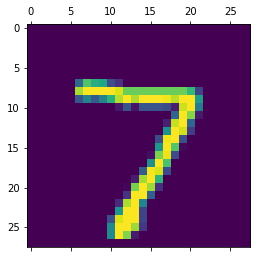

In [34]:
plt.matshow(X_test[0])

In [35]:
y_predicted[0]  # model has given below accuracy for each number from 1 to 10. The one with max value will be the digit.

array([0.3142373 , 0.40108943, 0.35123777, 0.41139898, 0.47451165,
       0.3816623 , 0.28532565, 0.80787724, 0.37402382, 0.5871766 ],
      dtype=float32)

**np.argmax finds a maximum element  from an array and returns the index of it**

In [36]:
np.argmax(y_predicted[0]) # wow it's a correct prediction. 

7

In [40]:
np.argmax(y_predicted[1]) # wow it's a correct prediction. 

2

In [37]:
y_predicted_labels = [np.argmax(i) for i in y_predicted] # take the max value for each of prediction

In [38]:
y_predicted_labels[:5]

[7, 2, 1, 0, 4]

## 3. EVALUATION

In [41]:
#Apply Confusion matrix 10*10
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 926,    2,    5,    9,    0,    3,   28,    1,    6,    0],
       [   0, 1110,    8,    4,    0,    1,    4,    0,    8,    0],
       [  19,   89,  783,   34,   16,    0,   32,   22,   36,    1],
       [   6,   50,   27,  860,    1,    2,    5,   24,   24,   11],
       [   2,   50,    3,    0,  761,    0,   28,    9,    3,  126],
       [  38,  114,    4,  203,   29,  383,   26,   42,   22,   31],
       [  27,   48,    6,    0,   14,   10,  852,    0,    1,    0],
       [   2,   71,   12,    2,   10,    0,    2,  902,    6,   21],
       [  22,   99,    9,   95,   12,    6,   16,   25,  660,   30],
       [  23,   43,    5,   10,   64,    0,    1,   85,    7,  771]])>

Text(69.0, 0.5, 'Truth')

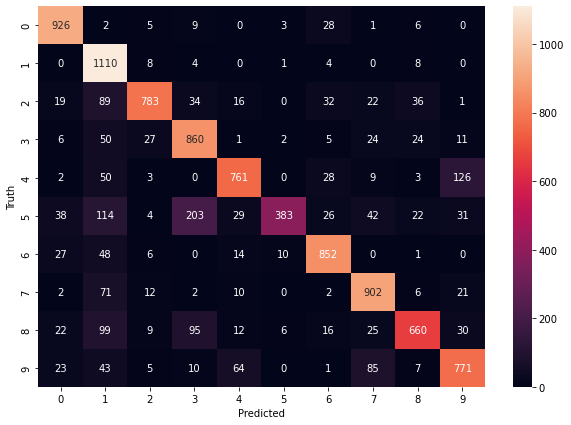

In [42]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')


## 4. APPLY HIDDEN LAYER

<h3 style='color:purple'>Using hidden layer</h3>


In [43]:
# Here 1st dense function: 100 is Hidden layer's(O/P) no of neorons
# Here 2nd dense function: it automatically takes input shape from previous layer output, we just need to mention o/p


model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation='relu'), # extra layer added
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 3s 1ms/step - loss: 1.2031 - accuracy: 0.7059
Epoch 2/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.4990 - accuracy: 0.8718
Epoch 3/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3895 - accuracy: 0.8932
Epoch 4/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3470 - accuracy: 0.9032
Epoch 5/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3228 - accuracy: 0.9080


> After adding hidden layer, accuracy increased to 90%

In [45]:
#Test/Evaluate the test dataset --> model.evaluate(X_test, ytest)
model.evaluate(X_test_flattened,y_test)

313/313 [==============================] - 0s 850us/step - loss: 0.3051 - accuracy: 0.9115


[0.30506134033203125, 0.9114999771118164]

> wow..accuracy increased from 80% to 91% due to inclusion of one additional layer in the model. 

Text(69.0, 0.5, 'Truth')

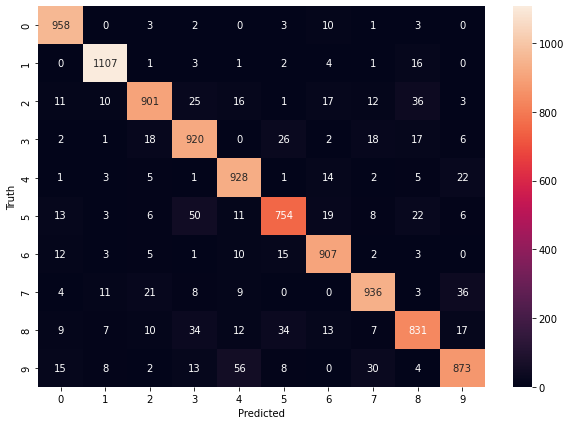

In [48]:
y_predicted = model.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

<h3 style='color:purple'>## 5.Using Flatten layer so that we don't have to call .reshape on input dataset</h3>

In [49]:
# Before keras.layers.Dense, use keras.layers.Flatten to flatten the input data

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # instead of flatening manually we can explicity mention as like this also, then algorithm will take care of flatenning. 
    
    keras.layers.Dense(100, activation='relu'), # Here no need to provide input_shape
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10) # pls note, here we are passing X_train not X_train_flatten. 

Epoch 1/10
1875/1875 [==============================] - 2s 1ms/step - loss: 1.2460 - accuracy: 0.6889: 1s - loss: 1.6 - ETA: 0s - loss: 1.407
Epoch 2/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.5236 - accuracy: 0.8635
Epoch 3/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3996 - accuracy: 0.8905
Epoch 4/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3519 - accuracy: 0.9010: 0s - loss: 0.356
Epoch 5/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3248 - accuracy: 0.9078
Epoch 6/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3069 - accuracy: 0.9122
Epoch 7/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2927 - accuracy: 0.9156
Epoch 8/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2807 - accuracy: 0.9192
Epoch 9/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2709 - accuracy: 0.9220
Epoch 10/10
1875/1875 [=

In [50]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 0s 899us/step - loss: 0.2536 - accuracy: 0.9265


[0.25360366702079773, 0.9265000224113464]

>  hmmm thats great, if the flatenning job is given to model, it also helps in increasing the accuracy. 